In [1]:
import mlflow
import mlflow.sklearn
import pandas as pd

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
model = mlflow.sklearn.load_model("models:/customer-segmentation@champion")

df = pd.read_csv("../data/raw/train.csv")
df["cluster"] = model.predict(df)
df["cluster"].value_counts(normalize=True).sort_index().round(3)

cluster
0    0.259
1    0.185
2    0.334
3    0.222
Name: proportion, dtype: float64

In [2]:
num_cols = ["Age", "Work_Experience", "Family_Size"]
profile_num = df.groupby("cluster")[num_cols].median()
profile_num.loc["all"] = df[num_cols].median()
profile_num

,Age,Work_Experience,Family_Size
cluster,,,
0,47.0,1.0,1.0
1,36.0,8.0,2.0
2,51.0,1.0,3.0
3,27.0,1.0,4.0
all,40.0,1.0,3.0


In [3]:
shares = pd.DataFrame({
    "male": df["Gender"].eq("Male"),
    "married": df["Ever_Married"].eq("Yes"),
    "graduated": df["Graduated"].eq("Yes"),
})
profile_bin = shares.groupby(df["cluster"]).mean()
profile_bin.loc["all"] = shares.mean()
profile_bin.round(2)

,male,married,graduated
cluster,,,
0,0.53,0.54,0.76
1,0.47,0.49,0.67
2,0.60,0.98,0.71
3,0.55,0.09,0.26
all,0.55,0.58,0.62


In [4]:
spending = pd.crosstab(df["cluster"], df["Spending_Score"], normalize="index")
spending = spending[["Low", "Average", "High"]]
spending.loc["all"] = df["Spending_Score"].value_counts(normalize=True)
spending.round(2)

Spending_Score,Low,Average,High
cluster,,,
0,1.00,0.00,0.00
1,0.69,0.24,0.07
2,0.00,0.58,0.41
3,0.97,0.02,0.00
all,0.60,0.24,0.15


In [5]:
profession = pd.crosstab(
    df["cluster"], df["Profession"].fillna("Missing"), normalize="index"
)
profession.loc["all"] = df["Profession"].fillna("Missing").value_counts(normalize=True)
profession.round(2)

Profession,Artist,Doctor,Engineer,Entertainment,Executive,Healthcare,Homemaker,Lawyer,Marketing,Missing
cluster,,,,,,,,,,
0,0.39,0.08,0.10,0.14,0.03,0.05,0.02,0.12,0.04,0.02
1,0.34,0.09,0.09,0.14,0.04,0.14,0.09,0.01,0.04,0.01
2,0.40,0.06,0.08,0.11,0.16,0.02,0.02,0.13,0.02,0.01
3,0.06,0.12,0.08,0.08,0.02,0.54,0.01,0.00,0.06,0.02
all,0.31,0.09,0.09,0.12,0.07,0.17,0.03,0.08,0.04,0.02


## Segment profiles

Each segment is described by the features that differ most from the overall population (row `all`). Statements marked *likely* are hypotheses, not facts from the data.

### Cluster 0 — Middle-aged singles, low spenders (26%)
- Live alone: median family size 1 (overall: 3).
- Older than average: median age 47 (overall: 40).
- 100% have a `Low` spending score.
- More graduates than average: 76% (overall: 62%).
- About half are married despite living alone — *likely* includes divorced or widowed customers.

**Marketing:** practical, budget-friendly offers; value for money over premium features.

### Cluster 1 — Experienced professionals, small families (19%)
- The only segment with long work experience: median 8 years (overall: 1).
- Median age 36, family size 2.
- Mostly `Low` spending (69%), but more `Average` spenders (24%) than clusters 0 and 3.
- Homemakers are three times more common than average (9% vs 3%).

**Marketing:** mid-range offers; emphasis on reliability and long-term value.

### Cluster 2 — Established families, high spenders (33%)
- Almost all are married: 98% (overall: 58%).
- Oldest segment: median age 51; family size 3 — *likely* with children.
- The only segment with high spending: 0% `Low`, 58% `Average`, 41% `High`.
- More executives (16% vs 7%) and lawyers (13% vs 8%) than average.

**Marketing:** the most valuable segment; premium and family-oriented offers, loyalty programs.

### Cluster 3 — Young healthcare workers, living with family (22%)
- Youngest segment: median age 27.
- Rarely married: 9% (overall: 58%), yet the largest families: median 4 — *likely* living with parents.
- Few graduates: 26% (overall: 62%).
- More than half work in healthcare: 54% (overall: 17%).
- Almost all have a `Low` spending score (97%).

**Marketing:** entry-level offers, financing and installment plans; a segment to grow over time.

### Key observation
Spending score is one of the main drivers of the segmentation: cluster 2 concentrates almost all `Average` and `High` spenders, while clusters 0 and 3 are almost entirely `Low`.

In [6]:
pd.crosstab(df["cluster"], df["Segmentation"], normalize="index").round(2)

Segmentation,A,B,C,D
cluster,,,,
0,0.38,0.26,0.15,0.22
1,0.29,0.20,0.19,0.32
2,0.18,0.31,0.43,0.08
3,0.14,0.10,0.13,0.63


In [7]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(df["Segmentation"], df["cluster"])
nmi = normalized_mutual_info_score(df["Segmentation"], df["cluster"])
print(f"ARI: {ari:.3f}")
print(f"NMI: {nmi:.3f}")

ARI: 0.098
NMI: 0.099


**Conclusions:**
- Agreement with the business segments is partial: ARI = 0.098, NMI = 0.099 (0 would mean a random split).
- Cluster 3 (young, unmarried, low spenders) strongly matches segment D: 63% vs ~25% baseline.
- Cluster 2 (established families, high spenders) mostly consists of segments C (43%) and B (31%), with almost no D (8%). The model merges B and C into one group.
- Cluster 0 moderately matches segment A (38%).
- Cluster 1 does not correspond to any single segment.
- Demographic features are enough to identify segment D and the B+C group, but not to separate A, B and C. The sales team likely used information not present in the data, such as purchase history.

## 2D visualization

Explained variance: 0.39


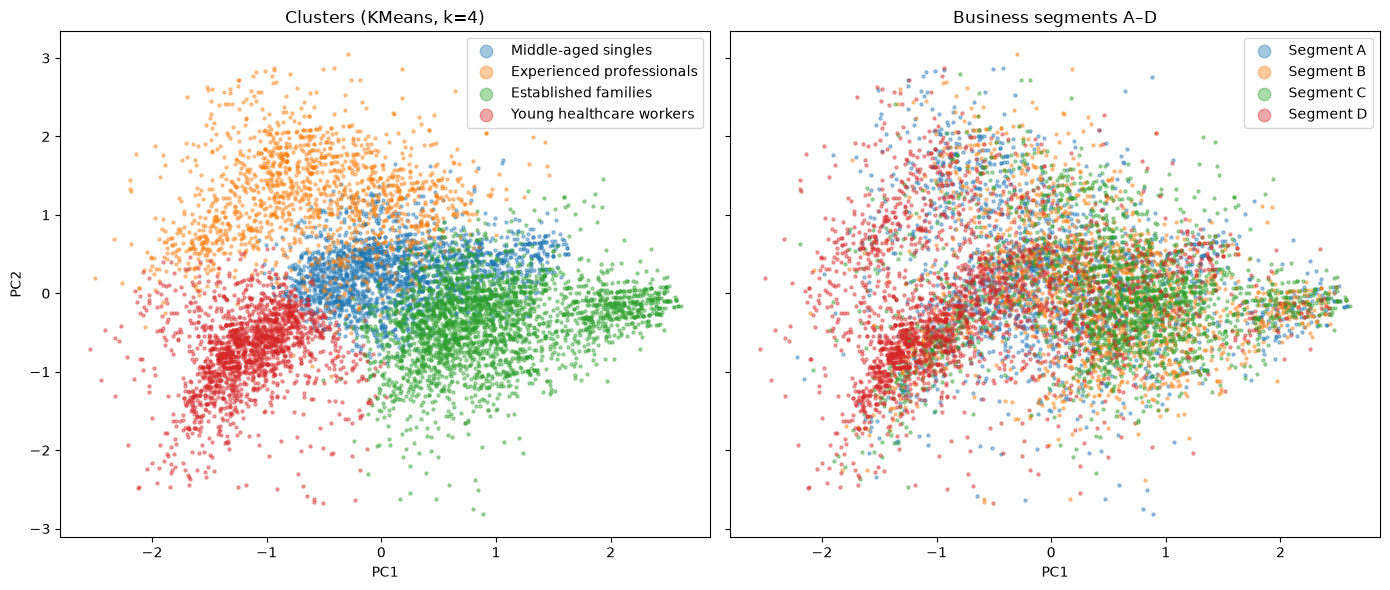

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_prep = model.named_steps["preprocess"].transform(df)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_prep)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2f}")

names = {
    0: "Middle-aged singles",
    1: "Experienced professionals",
    2: "Established families",
    3: "Young healthcare workers",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for cluster, name in names.items():
    mask = (df["cluster"] == cluster).to_numpy()
    axes[0].scatter(coords[mask, 0], coords[mask, 1], s=5, alpha=0.4, label=name)
axes[0].set_title("Clusters (KMeans, k=4)")

for segment in sorted(df["Segmentation"].unique()):
    mask = (df["Segmentation"] == segment).to_numpy()
    axes[1].scatter(
        coords[mask, 0], coords[mask, 1], s=5, alpha=0.4, label=f"Segment {segment}"
    )
axes[1].set_title("Business segments A–D")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.legend(markerscale=4)
axes[0].set_ylabel("PC2")
plt.tight_layout()

Path("../reports/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../reports/figures/clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusions:**
- Two principal components explain ~39% of the variance, so the picture is approximate.
- In this projection the four clusters occupy distinct regions; part of this sharpness comes from KMeans itself, which always splits the space into non-overlapping regions.
- Business segments are much more mixed. The clearest match is in the lower-left corner: young healthcare workers (cluster 3) and segment D occupy the same region.
- The established families region (cluster 2) corresponds to the area where segments C and B are concentrated.
- Segment A is spread across the whole projection, which agrees with its weak match to any cluster.